# 🔬 EDA Laboratory: `statsbomb_fa_women's_super_league_2019_2020_match_2275105.csv`
Execute the cells below to explore and clean the dataset. Modify parameters as needed.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
import sys
import warnings
warnings.filterwarnings('ignore')

# Append root directory to path so we can import local scripts
sys.path.append('../../') 
from scripts.db_uploader import upload_to_postgres

df = pd.read_csv('../../data/raw/statsbomb_fa_women\'s_super_league_2019_2020_match_2275105.csv', low_memory=False)
print(f'Dataset loaded: {{df.shape[0]}} rows, {{df.shape[1]}} columns')
df.head(3)

Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns


,ball_receipt_outcome,ball_recovery_offensive,ball_recovery_recovery_failure,block_deflection,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 442, 'lineup': [{'player': {'id'...",Manchester City WFC,746,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 41212, 'lineup': [{'player': {'i...",Chelsea FCW,971,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Manchester City WFC,746,00:00:00.000,Half Start,NaN


In [2]:
# 1. BASIC EXPLORATION
df.info()
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 3549 entries, 0 to 3548
Data columns (total 92 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ball_receipt_outcome            158 non-null    str    
 1   ball_recovery_offensive         1 non-null      object 
 2   ball_recovery_recovery_failure  6 non-null      object 
 3   block_deflection                4 non-null      object 
 4   carry_end_location              798 non-null    str    
 5   clearance_aerial_won            9 non-null      object 
 6   clearance_body_part             50 non-null     str    
 7   clearance_head                  19 non-null     object 
 8   clearance_left_foot             12 non-null     object 
 9   clearance_right_foot            19 non-null     object 
 10  counterpress                    85 non-null     object 
 11  dribble_nutmeg                  3 non-null      object 
 12  dribble_outcome                 32 non-null  

In [3]:
# 2. CATEGORICAL VARIABLES ENCODING (Label Encoding & Boolean Imputation)
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
for col in cat_cols:
    unique_vals = [str(x).lower() for x in df[col].dropna().unique()]
    if 'true' in unique_vals or 'false' in unique_vals:
        df[col] = df[col].fillna(False).map({True: 1, False: 0, 'True': 1, 'False': 0, '1': 1, '0': 0}).fillna(0).astype(int)
    else:
        df[col] = df[col].fillna('Unknown')
        df[col+'_encoded'] = LabelEncoder().fit_transform(df[col].astype(str))
df = df.dropna(how='all', axis=1)
print('Encoding and Imputation completed successfully.')

Encoding and Imputation completed successfully.


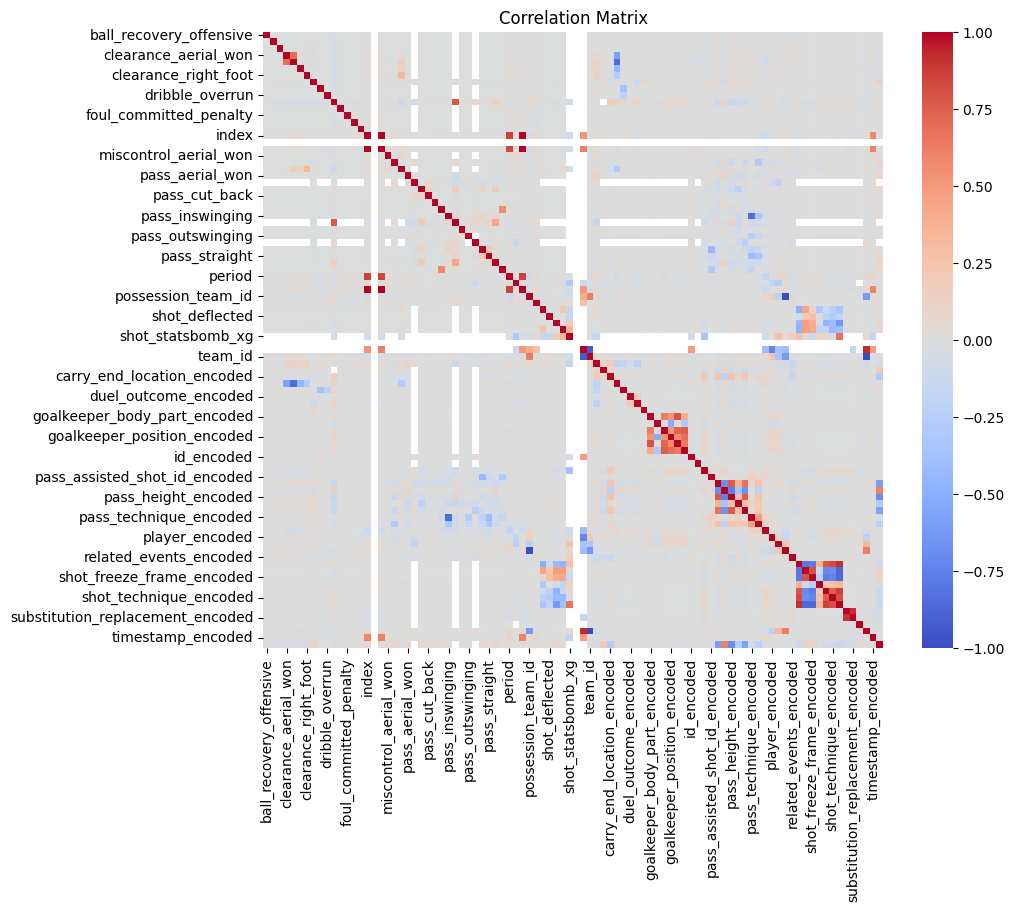

In [4]:
# 3. CORRELATION MATRIX
numerical_data = df.select_dtypes(include=np.number)
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_data.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## 🚀 FINISH EDA: DATABASE UPLOAD
When you are satisfied with the data cleaning, execute this cell to upload the polished DataFrame to PostgreSQL (DBeaver).

In [5]:
upload_to_postgres(df, table_name='statsbomb_fa_womens_super_league_2019_2020_match_2275105_clean')

⏳ Connecting to PostgreSQL to create/update table 'statsbomb_fa_womens_super_league_2019_2020_match_2275105_clean'...
✅ SUCCESS! 3549 rows securely loaded into SQL table 'statsbomb_fa_womens_super_league_2019_2020_match_2275105_clean'.
